In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 8: Learning What a True Cell Center Looks Like

**Objective:** Compare matched and unmatched blob detections to understand what image characteristics make a detection more likely to correspond to a true labeled cell.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- label LoG blob detections as matched or unmatched relative to the ground-truth centroids
- extract simple image features around each detection
- compare the appearance of matched and unmatched detections
- identify which features might help filter noisy candidate blobs

# 🧠 Background Theory

In Chapter 7, slice-by-slice LoG blob detection found more labeled centroids than the local-maxima baselines, but it also produced a very large number of extra candidate detections.

That means the blob detector may be useful as a **candidate generator**, but not as a final detector.

In this chapter, I will study the blob detections themselves.

I will separate blob detections into two groups:

- **matched detections**: detections close to a labeled centroid
- **unmatched detections**: detections not close to any labeled centroid

Then I will compare simple image features around those detections to learn what makes a candidate more likely to correspond to a true labeled cell.

# 🗺️ Chapter Roadmap

This notebook will proceed in six stages:

1. **Reload the sample, labels, and LoG detector**
2. **Label each blob detection as matched or unmatched**
3. **Extract simple patch-based features around each blob**
4. **Compare feature distributions between matched and unmatched detections**
5. **Visualize representative examples**
6. **Identify promising directions for candidate filtering**

# 📚 New Vocabulary

## Matched Detection
A predicted blob whose center falls within a chosen distance threshold of a ground-truth centroid.

## Unmatched Detection
A predicted blob that does not fall near any ground-truth centroid.

## Patch
A small square crop of pixels centered on a detection.

## Local Contrast
A measure of how much brighter a center point is than its local neighborhood.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 32.0 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import blob_log

In [4]:
from scipy.ndimage import gaussian_filter

print("Imports successful.")

Imports successful.


# Step 1 — Reload the Same Sample and Timepoint

To keep the comparison consistent, I will continue using the same training sample and the same labeled timepoint from Chapters 5–7.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

# Load image
volume = zarr.open(zarr_path, mode="r")
image = volume["0"]

# Load graph
geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

t = 8
frame_3d = image[t]
gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()

print("Frame shape:", frame_3d.shape)
print("Ground-truth nodes:", len(gt_nodes_t))
gt_nodes_t

Frame shape: (64, 256, 256)
Ground-truth nodes: 11


,node_id,t,z,y,x
82,114000000041,8,10,237,65
81,114000000040,8,15,184,60
87,114000000080,8,17,248,101
90,114000000084,8,18,2,116
89,114000000082,8,22,199,63
84,114000000043,8,25,208,115
83,114000000042,8,27,156,0
88,114000000081,8,28,122,100
80,114000000037,8,37,50,192
86,114000000063,8,40,198,98


# Step 2 — Recreate the LoG Blob Detector from Chapter 7

I will reuse the strictest LoG detector from Chapter 7 so that I can study which blob detections correspond to labeled cells and which do not.

In [6]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)

In [7]:
blob_pred_df = detect_blobs_log_3d_slicewise(frame_3d)

print("Blob detections:", len(blob_pred_df))
blob_pred_df.head()

Blob detections: 1478


,z,y,x,sigma
0,0,92,0,3.5
1,0,183,6,3.5
2,0,118,19,3.5
3,0,212,75,3.5
4,0,208,19,3.5


# Step 3 — Match Blob Detections to Ground Truth

To study the blob detections, I need to know which ones fall near a labeled centroid.

I will compute the distance from each blob detection to the nearest ground-truth centroid and label each detection as:

- **matched** if it falls within the matching radius
- **unmatched** otherwise

In [8]:
def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    distances = np.sqrt(((gt - pred) ** 2).sum(axis=2))
    return distances

In [9]:
blob_points = blob_pred_df[["z", "y", "x"]].to_numpy()

dist_blob = pairwise_distances_3d(gt_points, blob_points)

# distance from each blob to its nearest GT centroid
min_dist_pred = dist_blob.min(axis=0)

match_radius = 6
blob_pred_df = blob_pred_df.copy()
blob_pred_df["nearest_gt_dist"] = min_dist_pred
blob_pred_df["matched"] = blob_pred_df["nearest_gt_dist"] <= match_radius

blob_pred_df.head()

,z,y,x,sigma,nearest_gt_dist,matched
0,0,92,0,3.5,69.462220,False
1,0,183,6,3.5,38.652296,False
2,0,118,19,3.5,50.338852,False
3,0,212,75,3.5,28.231188,False
4,0,208,19,3.5,49.819675,False


In [10]:
blob_pred_df["matched"].value_counts()

matched
False    1453
True       25
Name: count, dtype: int64

# Step 4 — Extract Patch-Based Features Around Each Blob Detection

For each blob detection, I will extract a small patch from the corresponding z-slice and compute simple image features.

These features are meant to describe how the detection looks locally in the image.

In [11]:
def extract_patch_features(frame_3d, detections_df, patch_radius=4):
    """
    Extract simple 2D patch-based features for each detection.
    Uses a square patch of size (2*patch_radius + 1) centered on (y, x)
    within the detection's own z-slice.
    """
    rows = []

    z_max, y_max, x_max = frame_3d.shape

    for idx, row in detections_df.iterrows():
        z = int(row["z"])
        y = int(row["y"])
        x = int(row["x"])

        slice_2d = frame_3d[z]

        y0 = max(0, y - patch_radius)
        y1 = min(y_max, y + patch_radius + 1)
        x0 = max(0, x - patch_radius)
        x1 = min(x_max, x + patch_radius + 1)

        patch = slice_2d[y0:y1, x0:x1].astype(np.float32)

        center_intensity = float(slice_2d[y, x])
        patch_mean = float(patch.mean())
        patch_max = float(patch.max())
        patch_std = float(patch.std())
        local_contrast = center_intensity - patch_mean

        rows.append({
            "z": z,
            "y": y,
            "x": x,
            "sigma": row["sigma"],
            "nearest_gt_dist": row["nearest_gt_dist"],
            "matched": row["matched"],
            "center_intensity": center_intensity,
            "patch_mean": patch_mean,
            "patch_max": patch_max,
            "patch_std": patch_std,
            "local_contrast": local_contrast,
        })

    return pd.DataFrame(rows)

In [12]:
blob_features_df = extract_patch_features(frame_3d, blob_pred_df, patch_radius=4)

print("Feature rows:", len(blob_features_df))
blob_features_df.head()

Feature rows: 1478


,z,y,x,sigma,nearest_gt_dist,matched,center_intensity,patch_mean,patch_max,patch_std,local_contrast
0,0,92,0,3.5,69.462220,False,1280.0,907.822205,1280.0,174.333572,372.177795
1,0,183,6,3.5,38.652296,False,1250.0,1016.234558,1286.0,158.421249,233.765442
2,0,118,19,3.5,50.338852,False,867.0,742.172852,920.0,97.855751,124.827148
3,0,212,75,3.5,28.231188,False,1028.0,864.765442,1050.0,113.143227,163.234558
4,0,208,19,3.5,49.819675,False,885.0,822.703674,928.0,76.585213,62.296326


# Step 5 — Compare Matched and Unmatched Blob Detections

Now I will compare the simple image features between matched and unmatched blob detections.

The goal is to see whether true-like detections look systematically different from noisy detections.

In [13]:
feature_cols = [
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "sigma"
]

feature_summary = blob_features_df.groupby("matched")[feature_cols].agg(["mean", "median", "std"])
feature_summary

center_intensity                       patch_mean               \
                    mean  median         std         mean       median   
matched                                                                  
False        1603.238128  1588.0  351.223156  1374.736350  1375.456787   
True         1563.000000  1463.0  338.978982  1350.607903  1296.814819   

                       patch_max                       patch_std              \
                std         mean  median         std        mean      median   
matched                                                                        
False    302.770022  1664.584997  1660.0  364.615795  172.158999  162.866547   
True     259.871198  1615.120000  1523.0  342.800029  154.032273  147.010788   

                   local_contrast                             sigma         \
               std           mean      median         std      mean median   
matched                                                                      
False    65.658609     228.501778  203.711121  120.860064  3.478665    3.5   
True     54.971331     212.392097  189.000000  104.637774  3.500000    3.5   

                   
              std  
matched            
False    0.119798  
True     0.000000

In [14]:
blob_pred_df["matched"].value_counts()

matched
False    1453
True       25
Name: count, dtype: int64

# Step 6 — Visualize Feature Distributions

The summary statistics suggest that matched and unmatched blob detections may not differ dramatically in raw brightness alone.

To inspect this more clearly, I will plot the distributions of several features for the two groups.

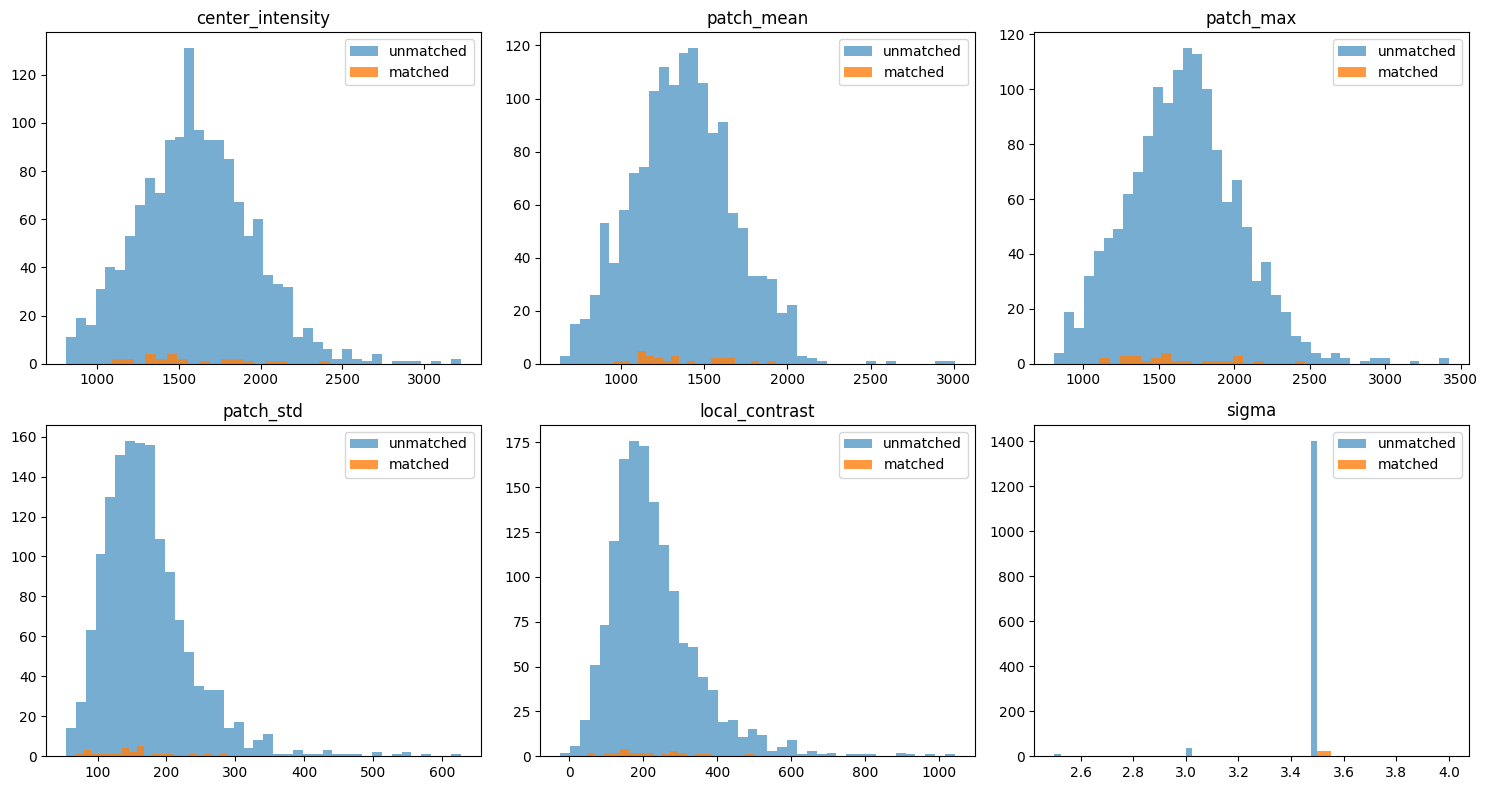

In [15]:
feature_cols = [
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "sigma"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    matched_vals = blob_features_df.loc[blob_features_df["matched"], col]
    unmatched_vals = blob_features_df.loc[~blob_features_df["matched"], col]

    ax.hist(unmatched_vals, bins=40, alpha=0.6, label="unmatched")
    ax.hist(matched_vals, bins=20, alpha=0.8, label="matched")
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

# Step 7 — Inspect Example Patches from Matched and Unmatched Detections

Feature summaries are useful, but I also want to look directly at the image patches around detections.

This will help me understand whether matched detections look systematically different from unmatched detections in ways that simple summary statistics might miss.

In [16]:
def get_patch(slice_2d, y, x, patch_radius=8):
    y0 = max(0, y - patch_radius)
    y1 = min(slice_2d.shape[0], y + patch_radius + 1)
    x0 = max(0, x - patch_radius)
    x1 = min(slice_2d.shape[1], x + patch_radius + 1)
    return slice_2d[y0:y1, x0:x1]

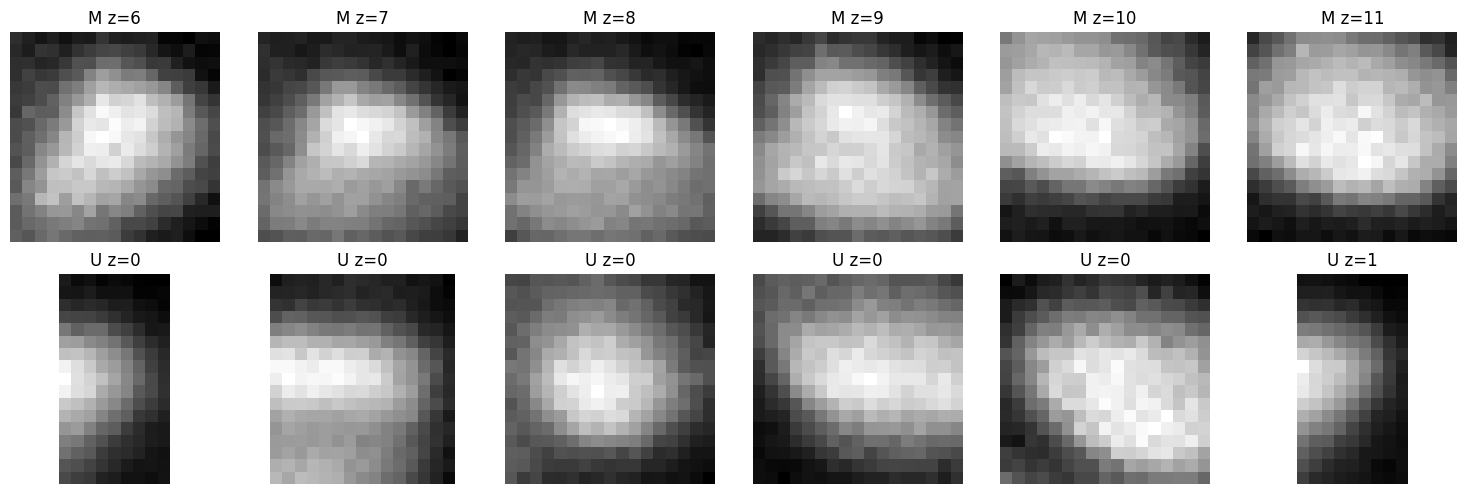

In [17]:
matched_examples = blob_features_df[blob_features_df["matched"]].head(6)
unmatched_examples = blob_features_df[~blob_features_df["matched"]].head(6)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

# Top row: matched examples
for i, (_, row) in enumerate(matched_examples.iterrows()):
    z, y, x = int(row["z"]), int(row["y"]), int(row["x"])
    patch = get_patch(frame_3d[z], y, x, patch_radius=8)

    axes[0, i].imshow(patch, cmap="gray")
    axes[0, i].set_title(f"M z={z}")
    axes[0, i].axis("off")

# Bottom row: unmatched examples
for i, (_, row) in enumerate(unmatched_examples.iterrows()):
    z, y, x = int(row["z"]), int(row["y"]), int(row["x"])
    patch = get_patch(frame_3d[z], y, x, patch_radius=8)

    axes[1, i].imshow(patch, cmap="gray")
    axes[1, i].set_title(f"U z={z}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# 📊 Results

In this chapter, I analyzed the strict LoG blob detections from Chapter 7 to understand how matched and unmatched candidate detections differ.

## Blob detection set
- **Total blob detections:** 1478
- **Matched detections:** 25
- **Unmatched detections:** 1453

## Feature comparison
For each blob detection, I extracted a 2D patch from its z-slice and computed:

- center intensity
- patch mean
- patch max
- patch standard deviation
- local contrast
- LoG sigma

## Main observation
The matched and unmatched detections showed substantial overlap in simple intensity-based features. Raw brightness and local contrast alone do not appear sufficient to separate GT-like detections from the large number of unmatched blob candidates.

# 🔍 Analysis

This notebook suggests that the main challenge is not simply finding bright points, but distinguishing GT-like detections from many visually similar candidate blobs.

## Main findings

### 1. Simple intensity features are weak separators
Matched and unmatched detections overlap heavily in center intensity, patch mean, patch max, patch standard deviation, and local contrast.

### 2. Patch appearance appears more informative than raw brightness
Visual inspection suggests that matched detections often look like more centered, coherent nucleus-like blobs, while many unmatched detections look like partial blobs, edge fragments, or off-center structures.

### 3. The unmatched class is probably heterogeneous
Unmatched detections likely include:
- false positives
- duplicate detections
- partial / edge detections
- real biological cells that are not included in the sparse ground-truth labels

## Takeaway
The next stage should focus on building a smarter candidate filter using spatial, shape, and 3D context features rather than relying only on raw intensity.

# 📝 What I Learned

Today I learned that:

- LoG candidate detections can be separated into matched and unmatched groups for analysis
- simple patch-level intensity features do not strongly distinguish GT-like detections from unmatched candidates
- visual patch inspection suggests that centering, shape coherence, and local context may matter more than raw brightness
- the sparse labels make the “negative” class ambiguous, so future filtering should be framed as ranking GT-like detections rather than classifying all unmatched blobs as biologically false

# 🚀 Next Steps

## Chapter 9 — Build a Candidate Filter for LoG Blob Detections

In the next notebook, I want to build a simple scoring model that predicts whether a blob detection is GT-like.

Possible new features:

- distance from patch center to brightest pixel
- patch center-of-mass offset
- border distance / edge-truncation indicators
- brightness consistency across neighboring z-slices
- local 3D support around the candidate
- patch asymmetry or shape features

Then I can use those features to rank or filter blob detections before moving on to tracking.